In [4]:
#1
import threading
import time

SALDO_AWAL = 1_000_000
JUMLAH_THREAD = 10
JUMLAH_TRANSAKSI = 10_000
JUMLAH_PERCOBAAN = 3


def jalankan_tanpa_lock():
    saldo = SALDO_AWAL

    def transaksi():
        nonlocal saldo

        for _ in range(JUMLAH_TRANSAKSI):
            temp = saldo
            time.sleep(0)
            saldo = temp - 1
            
            temp = saldo
            time.sleep(0)
            saldo = temp + 1

    threads = []

    for _ in range(JUMLAH_THREAD):
        t = threading.Thread(target=transaksi)
        threads.append(t)
        t.start()

    for t in threads:
        t.join()

    return saldo


def jalankan_dengan_lock():
    saldo = SALDO_AWAL
    lock = threading.Lock()

    def transaksi():
        nonlocal saldo

        for _ in range(JUMLAH_TRANSAKSI):
            with lock:
                temp = saldo
                time.sleep(0)
                saldo = temp - 1
                
                temp = saldo
                time.sleep(0)
                saldo = temp + 1

    threads = []

    for _ in range(JUMLAH_THREAD):
        t = threading.Thread(target=transaksi)
        threads.append(t)
        t.start()

    for t in threads:
        t.join()

    return saldo


print("TANPA LOCK")

for i in range(JUMLAH_PERCOBAAN):
    saldo_akhir = jalankan_tanpa_lock()
    print(f"Percobaan {i + 1}: saldo akhir = {saldo_akhir:,}")


print("\n DENGAN LOCK")

for i in range(JUMLAH_PERCOBAAN):
    saldo_akhir = jalankan_dengan_lock()
    print(f"Percobaan {i + 1}: saldo akhir = {saldo_akhir:,}")

# Pada percobaan Tanpa Lock, beberapa thread mengakses dan mengubah variabel saldo secara bersamaan. 
# Karena tidak ada pengaturan akses, terjadi race condition, sehingga nilai saldo akhir dapat berubah dan tidak selalu kembali ke 1.000.000.
# Pada percobaan Dengan Lock, hanya satu thread yang dapat mengakses dan mengubah saldo pada satu waktu. Hal ini mencegah race condition sehingga saldo akhir tetap 1.000.000 pada setiap percobaan.

TANPA LOCK
Percobaan 1: saldo akhir = 999,998
Percobaan 2: saldo akhir = 999,999
Percobaan 3: saldo akhir = 999,999

 DENGAN LOCK
Percobaan 1: saldo akhir = 1,000,000
Percobaan 2: saldo akhir = 1,000,000
Percobaan 3: saldo akhir = 1,000,000


In [5]:
#2
import threading
import queue
import time

q = queue.Queue()
print_lock = threading.Lock()

NUM_CONSUMERS = 3
NUM_ITEMS = 6


def safe_print(text):
    with print_lock:
        print(text, flush=True)


def producer():
    for i in range(NUM_ITEMS):
        item = f"Data-{i + 1}"
        q.put(item)
        safe_print(f"Producer menghasilkan {item}")
        time.sleep(0.1)

    safe_print("Producer selesai.")


def consumer(consumer_id):
    while True:
        item = q.get()

        if item is None:
            q.task_done()
            safe_print(f"Consumer {consumer_id} berhenti.")
            break

        safe_print(f"Consumer {consumer_id} memproses {item}")
        time.sleep(0.2)
        q.task_done()


producer_thread = threading.Thread(target=producer)

consumer_threads = []

for i in range(NUM_CONSUMERS):
    t = threading.Thread(
        target=consumer,
        args=(i + 1,)
    )
    consumer_threads.append(t)
    t.start()

producer_thread.start()

producer_thread.join()

for _ in range(NUM_CONSUMERS):
    q.put(None)

q.join()

for t in consumer_threads:
    t.join()

print("Semua consumer selesai.")

Producer menghasilkan Data-1
Consumer 1 memproses Data-1
Producer menghasilkan Data-2
Consumer 2 memproses Data-2
Producer menghasilkan Data-3
Consumer 3 memproses Data-3
Producer menghasilkan Data-4
Consumer 1 memproses Data-4
Producer menghasilkan Data-5
Consumer 2 memproses Data-5
Producer menghasilkan Data-6
Consumer 3 memproses Data-6
Producer selesai.
Consumer 1 berhenti.
Consumer 2 berhenti.
Consumer 3 berhenti.
Semua consumer selesai.


max_workers =  2 | waktu eksekusi = 2.54 detik
max_workers =  4 | waktu eksekusi = 1.32 detik
max_workers =  8 | waktu eksekusi = 0.72 detik
max_workers = 16 | waktu eksekusi = 0.41 detik


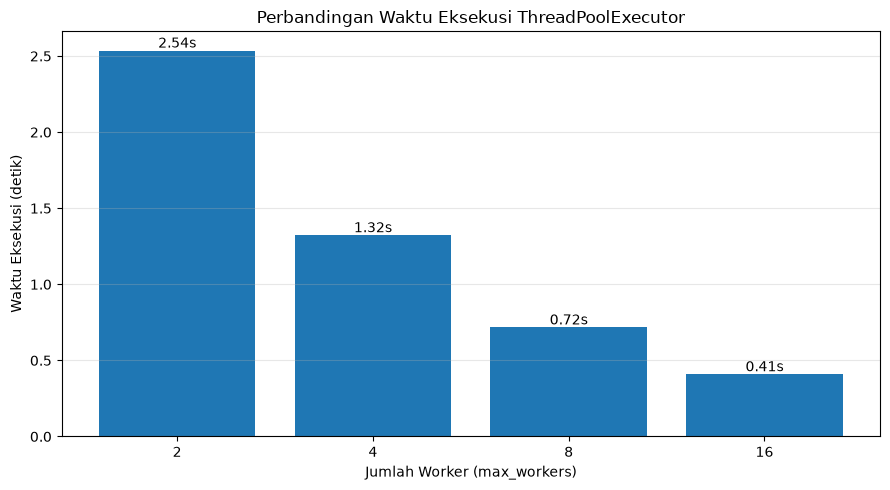


=== ANALISIS ===
Berdasarkan hasil pengujian, penggunaan 16 worker menghasilkan waktu eksekusi tercepat, yaitu 0.41 detik.
Penambahan jumlah worker memungkinkan beberapa task dijalankan secara bersamaan sehingga waktu eksekusi cenderung lebih singkat.
Namun, semakin banyak worker tidak selalu membuat program semakin cepat karena terdapat overhead dalam pengelolaan thread.


In [7]:
from concurrent.futures import ThreadPoolExecutor
import time
import matplotlib.pyplot as plt

JUMLAH_TASK = 50

def task(n):
    time.sleep(0.1)  
    return n


worker_values = [2, 4, 8, 16]
waktu_eksekusi = []

for workers in worker_values:
    mulai = time.perf_counter()

    with ThreadPoolExecutor(max_workers=workers) as executor:
        hasil = list(executor.map(task, range(JUMLAH_TASK)))

    selesai = time.perf_counter()
    waktu = selesai - mulai
    waktu_eksekusi.append(waktu)

    print(f"max_workers = {workers:2d} | "
          f"waktu eksekusi = {waktu:.2f} detik")

plt.figure(figsize=(9, 5))

bars = plt.bar(
    [str(x) for x in worker_values],
    waktu_eksekusi
)

plt.title("Perbandingan Waktu Eksekusi ThreadPoolExecutor")
plt.xlabel("Jumlah Worker (max_workers)")
plt.ylabel("Waktu Eksekusi (detik)")
plt.grid(axis="y", alpha=0.3)

for bar, waktu in zip(bars, waktu_eksekusi):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{waktu:.2f}s",
        ha="center"
    )

plt.tight_layout()
plt.show()


print("\n=== ANALISIS ===")

worker_tercepat = worker_values[waktu_eksekusi.index(min(waktu_eksekusi))]
waktu_tercepat = min(waktu_eksekusi)

print(
    f"Berdasarkan hasil pengujian, penggunaan {worker_tercepat} worker "
    f"menghasilkan waktu eksekusi tercepat, yaitu {waktu_tercepat:.2f} detik."
)

print(
    "Penambahan jumlah worker memungkinkan beberapa task dijalankan "
    "secara bersamaan sehingga waktu eksekusi cenderung lebih singkat."
)

print(
    "Namun, semakin banyak worker tidak selalu membuat program semakin cepat "
    "karena terdapat overhead dalam pengelolaan thread."
)

In [ ]:
# 4 Refleksi
# Threading Python cocok digunakan pada pekerjaan I/O-bound, seperti mengunduh file, membaca data, atau melakukan request ke server.
# Dengan threading, beberapa pekerjaan dapat berjalan secara bersamaan sehingga waktu tunggu saat proses I/O dapat dimanfaatkan. 
# Namun, threading kurang cocok untuk pekerjaan CPU-bound karena adanya GIL pada CPython yang membatasi eksekusi bytecode Python secara bersamaan. 
# Untuk pekerjaan yang membutuhkan CPU secara intensif, multiprocessing lebih sesuai karena dapat menggunakan beberapa proses dan core CPU. 
# Jadi, pemilihan antara threading dan multiprocessing harus disesuaikan dengan jenis pekerjaan yang dilakukan.